In [1]:
from google.colab import drive
drive.mount("/content/gdrive")

Mounted at /content/gdrive


In [2]:
path = "/content/gdrive/MyDrive/Praktikum/Praktikum07/Data"

In [8]:
import pandas as pd

df = pd.read_csv(path + '/apples_and_oranges.csv')

print(df.head())
df.info()
df.describe()

   Weight  Size   Class
0      69  4.39  orange
1      69  4.21  orange
2      65  4.09  orange
3      72  5.85   apple
4      67  4.70  orange
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Weight  40 non-null     int64  
 1   Size    40 non-null     float64
 2   Class   40 non-null     object 
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ KB


,Weight,Size
count,40.000000,40.000000
mean,70.200000,4.922750
std,3.039906,0.590063
min,65.000000,4.010000
25%,68.000000,4.360000
50%,70.000000,4.930000
75%,73.000000,5.472500
max,75.000000,5.850000


In [15]:
df["Class"].unique()

array(['orange', 'apple'], dtype=object)

In [16]:
df["Class"].value_counts()

,count
Class,
orange,20
apple,20


In [17]:
X = df[['Weight','Size']]

# Kolom target (label)
Y = df['Class']

In [18]:
X.head()

,Weight,Size
0,69,4.39
1,69,4.21
2,65,4.09
3,72,5.85
4,67,4.70


In [14]:
Y.head()

,Class
0,orange
1,orange
2,orange
3,apple
4,orange


In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
# Membuat model SVM dengan kernel linear
model = SVC(kernel='linear')
model.fit(X_train, Y_train)

SVC(kernel='linear')

In [23]:
Y_pred = model.predict(X_test)
# Akurasi
print(f"Akurasi: {accuracy_score(Y_test, Y_pred) * 100:.2f}%")
# Laporan klasifikasi
print("\nLaporan Klasifikasi:\n", classification_report(Y_test, Y_pred))

Akurasi: 100.00%

Laporan Klasifikasi:
               precision    recall  f1-score   support

       apple       1.00      1.00      1.00         3
      orange       1.00      1.00      1.00         5

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8




Confusion Matrix:
 [[3 0]
 [0 5]]


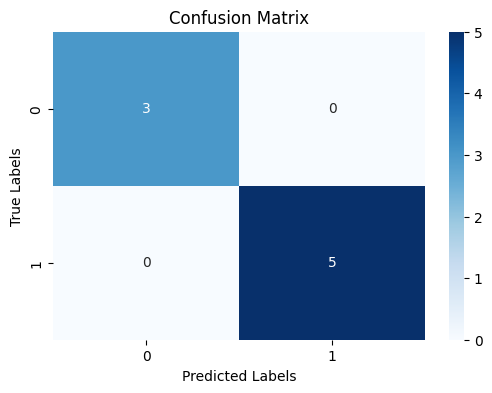

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

print("\nConfusion Matrix:\n", confusion_matrix(Y_test, Y_pred))

# Buat confusion matrix
cm = confusion_matrix(Y_test, Y_pred)

# Jika kamu tahu nama kelas (opsional, agar lebih informatif)
# misalnya: class_names = ['Negatif', 'Positif']
# maka tambahkan ke heatmap di bagian "xticklabels" dan "yticklabels"

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

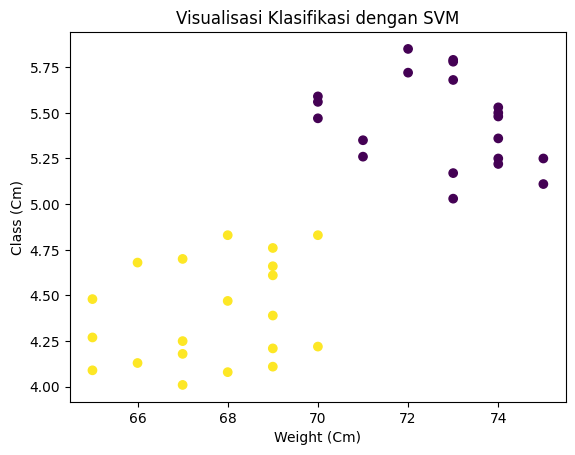

In [29]:
import matplotlib.pyplot as plt

plt.scatter(df['Weight'], df['Size'], c=df['Class'].astype('category').cat.codes)
plt.xlabel('Weight (Cm)')
plt.ylabel('Class (Cm)')
plt.title('Visualisasi Klasifikasi dengan SVM')
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from mpl_toolkits.mplot3d import Axes3Dr

# 3. Encode label (ubah teks jadi angka)
le = LabelEncoder()
df['SpeciesEncoded'] = le.fit_transform(df['Species'])


# 8. Plot 3D hasil klasifikasi
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Warna untuk tiap kelas
colors = ['r', 'g', 'b']
labels = le.classes_

# Plot tiap spesies dengan warna berbeda
for i, species in enumerate(labels):
    subset = df[df['SpeciesEncoded'] == i]
    ax.scatter(
        subset['SepalLengthCm'],
        subset['PetalLengthCm'],
        subset['PetalWidthCm'],
        color=colors[i],
        label=species,
        s=50
    )

ax.set_xlabel('Sepal Length (cm)')
ax.set_ylabel('Petal Length (cm)')
ax.set_zlabel('Petal Width (cm)')
ax.set_title('3D Visualisasi Klasifikasi Iris dengan SVM')
ax.legend()
plt.show()

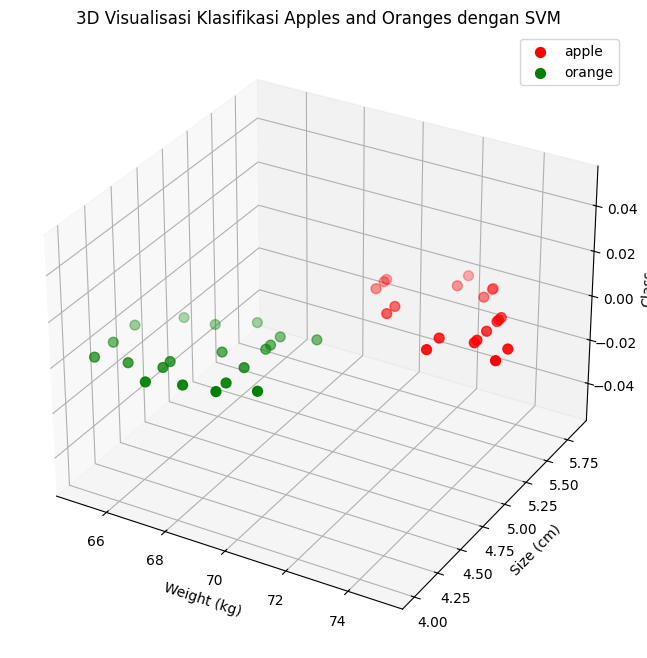

In [27]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from mpl_toolkits.mplot3d import Axes3D
#3. Encode label (ubah teks jadi angka)
le=LabelEncoder()
df['ClassEncoded'] = le.fit_transform(df['Class'])
#8. Plot 3D hasil klasifikasi
fig=plt.figure(figsize=(10, 8))
ax=fig.add_subplot(111, projection='3d')
# Warna untuk tiap kelas
colors = ['r', 'g', 'b']
labels = le.classes_
# Plot tiap spesies dengan warna berbeda for i, species in enumerate (labels):
for i, species in enumerate(labels):
  subset = df[df['ClassEncoded'] == i]
  ax.scatter(
              subset['Weight'],
              subset['Size'],
              color=colors[i],
              label=species,
              s = 50
            )
ax.set_xlabel('Weight (kg)')
ax.set_ylabel('Size (cm)')
ax.set_zlabel('Class')
ax.set_title('3D Visualisasi Klasifikasi Apples and Oranges dengan SVM')
ax.legend()
plt.show()
